<a href="https://colab.research.google.com/github/Samrile/Diabetic-Retinopathy-Classification/blob/main/Diabetic-Retinopathy-Classification/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import userdata

kaggle_token = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle token loaded:", kaggle_token is not None)

Kaggle token loaded: True


In [3]:
!pip install -q kaggle

In [4]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle connected!")

Kaggle connected!


In [5]:
!kaggle datasets list -s "diabetic retinopathy" -p 5

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
mohamedabdalkader/retinal-disease-detection                     Retinal Disease Detection                          2297030359  2025-08-27 20:31:03.600000            942         11                1  
abhinav099802/eye-disease-image-dataset                         Eye Disease Image Dataset - Mendeley               3940685596  2025-07-05 19:23:06.143000            586         13             0.75  
matteocacciolamotork/diabetic-retinopathy-segmentation          Diabetic Retinopathy Segmentation                    28899016  2024-04-05 07:54:31.507000             23          2           0.3125  
kirol

In [9]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.8 MB/s eta 0:00:00


In [1]:
import kaggle

print(kaggle.__version__)

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token
2.2.4


In [2]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle authentication loaded.")

Kaggle authentication loaded.


In [7]:
!kaggle datasets files -d poojita2305/diabetic-retinopathy-detection

Next Page Token = CfDJ8OasvsPNS7VMiSwiBm2YVpOC8dxr5xtNGIR7K4JKvfSSI2MPskDnwIe7EMANaj_pOtJ6IcD5w3AiVzcDz8x89DaC2a_2lHgAobgUu7ifGDYb27HFvBcxygynOcgbxcTmhjoXoskUEz2XVORcMq9I-jOZu_kH341uRSF83bsc0Y6XVUO5VDc
name                                              size  creationDate                
----------------------------------------------  ------  --------------------------  
gaussian_filtered_images/Mild/0024cdab0c1e.png  100663  2021-06-08 14:41:49.353000  
gaussian_filtered_images/Mild/00cb6555d108.png  103567  2021-06-08 14:41:49.377000  
gaussian_filtered_images/Mild/0124dffecf29.png  105339  2021-06-08 14:41:49.402000  
gaussian_filtered_images/Mild/01b3aed3ed4c.png  101562  2021-06-08 14:41:49.361000  
gaussian_filtered_images/Mild/0369f3efe69b.png  106987  2021-06-08 14:41:49.372000  
gaussian_filtered_images/Mild/03e25101e8e8.png  115379  2021-06-08 14:41:49.354000  
gaussian_filtered_images/Mild/04ac765f91a1.png  107971  2021-06-08 14:41:49.370000  
gaussian_filtered_images/Mild/059

In [8]:
!kaggle datasets download -d poojita2305/diabetic-retinopathy-detection -p /content

Dataset URL: https://www.kaggle.com/datasets/poojita2305/diabetic-retinopathy-detection
License(s): unknown
100% 349M/349M [00:10<00:00, 35.5MB/s]



In [9]:
!ls -lh /content

total 350M
-rw-r--r-- 1 root root 350M Jun  8  2021 diabetic-retinopathy-detection.zip
drwxr-xr-x 1 root root 4.0K Sep  4 13:25 sample_data


In [10]:
import zipfile

zip_path = "/content/diabetic-retinopathy-detection.zip"
extract_path = "/content/diabetic_retinopathy"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [11]:
import os

for root, dirs, files in os.walk("/content/diabetic_retinopathy"):
    print(root, "→", len(files), "files")

/content/diabetic_retinopathy → 0 files
/content/diabetic_retinopathy/gaussian_filtered_images → 0 files
/content/diabetic_retinopathy/gaussian_filtered_images/Mild → 370 files
/content/diabetic_retinopathy/gaussian_filtered_images/Severe → 193 files
/content/diabetic_retinopathy/gaussian_filtered_images/Proliferate_DR → 295 files
/content/diabetic_retinopathy/gaussian_filtered_images/Moderate → 999 files
/content/diabetic_retinopathy/gaussian_filtered_images/No_DR → 1805 files


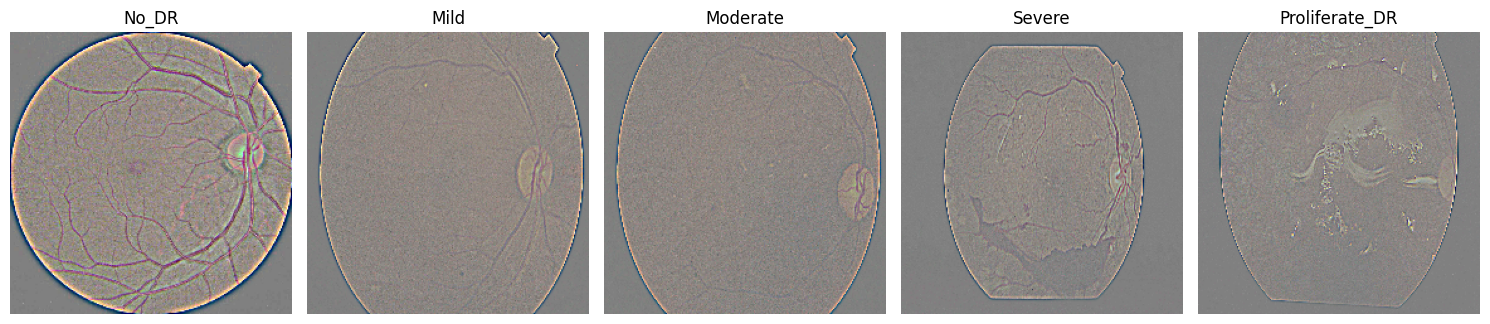

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

base_path = "/content/diabetic_retinopathy/gaussian_filtered_images"

classes = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferate_DR"
]

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(base_path, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
from PIL import Image
import os

base_path = "/content/diabetic_retinopathy/gaussian_filtered_images"

for class_name in classes:
    class_path = os.path.join(base_path, class_name)

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    print(f"{class_name}:")
    print("  Size:", image.size)
    print("  Mode:", image.mode)
    print()

No_DR:
  Size: (224, 224)
  Mode: RGB

Mild:
  Size: (224, 224)
  Mode: RGB

Moderate:
  Size: (224, 224)
  Mode: RGB

Severe:
  Size: (224, 224)
  Mode: RGB

Proliferate_DR:
  Size: (224, 224)
  Mode: RGB



In [17]:
import pandas as pd

base_path = "/content/diabetic_retinopathy/gaussian_filtered_images"

classes = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferate_DR"
]

data = []

for class_name in classes:
    class_path = os.path.join(base_path, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        data.append({
            "image_path": image_path,
            "label": class_name
        })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("\nFirst 5 rows:")
print(df.head())

print("\nClass distribution:")
print(df["label"].value_counts())

Total images: 3662

First 5 rows:
                                          image_path  label
0  /content/diabetic_retinopathy/gaussian_filtere...  No_DR
1  /content/diabetic_retinopathy/gaussian_filtere...  No_DR
2  /content/diabetic_retinopathy/gaussian_filtere...  No_DR
3  /content/diabetic_retinopathy/gaussian_filtere...  No_DR
4  /content/diabetic_retinopathy/gaussian_filtere...  No_DR

Class distribution:
label
No_DR             1805
Moderate           999
Mild               370
Proliferate_DR     295
Severe             193
Name: count, dtype: int64


In [18]:
import pandas as pd

base_path = "/content/diabetic_retinopathy/gaussian_filtered_images"

classes = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferate_DR"
]

data = []

for class_name in classes:
    class_path = os.path.join(base_path, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        data.append({
            "image_path": image_path,
            "label": class_name
        })

df = pd.DataFrame(data)

print("Total images:", len(df))

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nFirst 5 rows:")
display(df.head())

Total images: 3662

Class distribution:
label
No_DR             1805
Moderate           999
Mild               370
Proliferate_DR     295
Severe             193
Name: count, dtype: int64

First 5 rows:


,image_path,label
0,/content/diabetic_retinopathy/gaussian_filtere...,No_DR
1,/content/diabetic_retinopathy/gaussian_filtere...,No_DR
2,/content/diabetic_retinopathy/gaussian_filtere...,No_DR
3,/content/diabetic_retinopathy/gaussian_filtere...,No_DR
4,/content/diabetic_retinopathy/gaussian_filtere...,No_DR


In [19]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images: 2929
Validation images: 366
Test images: 367


##Check class distribution in each split

In [20]:
print("Training distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

Training distribution:
label
No_DR             1444
Moderate           799
Mild               296
Proliferate_DR     236
Severe             154
Name: count, dtype: int64

Validation distribution:
label
No_DR             180
Moderate          100
Mild               37
Proliferate_DR     29
Severe             20
Name: count, dtype: int64

Test distribution:
label
No_DR             181
Moderate          100
Mild               37
Proliferate_DR     30
Severe             19
Name: count, dtype: int64


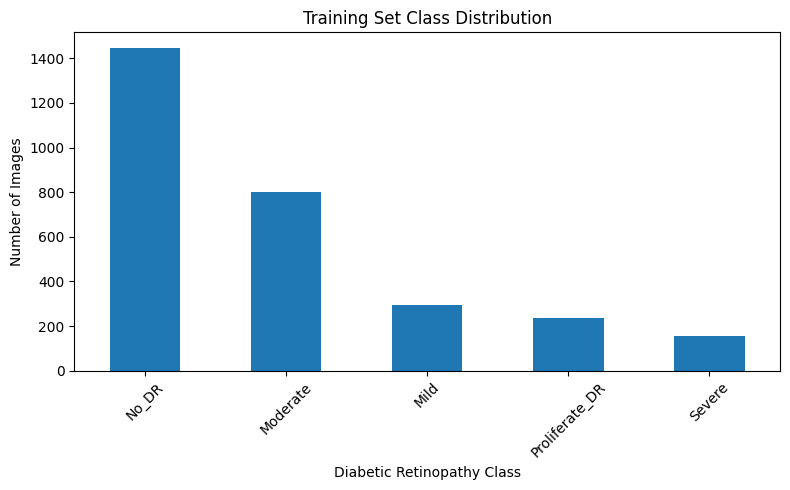

In [21]:
import matplotlib.pyplot as plt

class_counts = train_df["label"].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")

plt.title("Training Set Class Distribution")
plt.xlabel("Diabetic Retinopathy Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

label_map = {
    "No_DR": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3,
    "Proliferate_DR": 4
}

def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].map(label_map).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    def load_image(image_path, label):
        image = tf.io.read_file(image_path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, IMG_SIZE)

        return image, label

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

print("TensorFlow datasets created successfully!")

TensorFlow datasets created successfully!


In [23]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image data type:", images.dtype)
print("Pixel range:", images[0].numpy().min(), "to", images[0].numpy().max())

print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Pixel range: 0.0 to 255.0
First 10 labels: [4 0 0 2 1 0 4 2 0 3]


In [24]:
normalization_layer = tf.keras.layers.Rescaling(
    1.0 / 255
)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Normalization applied successfully!")

Normalization applied successfully!


In [25]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Data augmentation applied to training dataset!")

Data augmentation applied to training dataset!


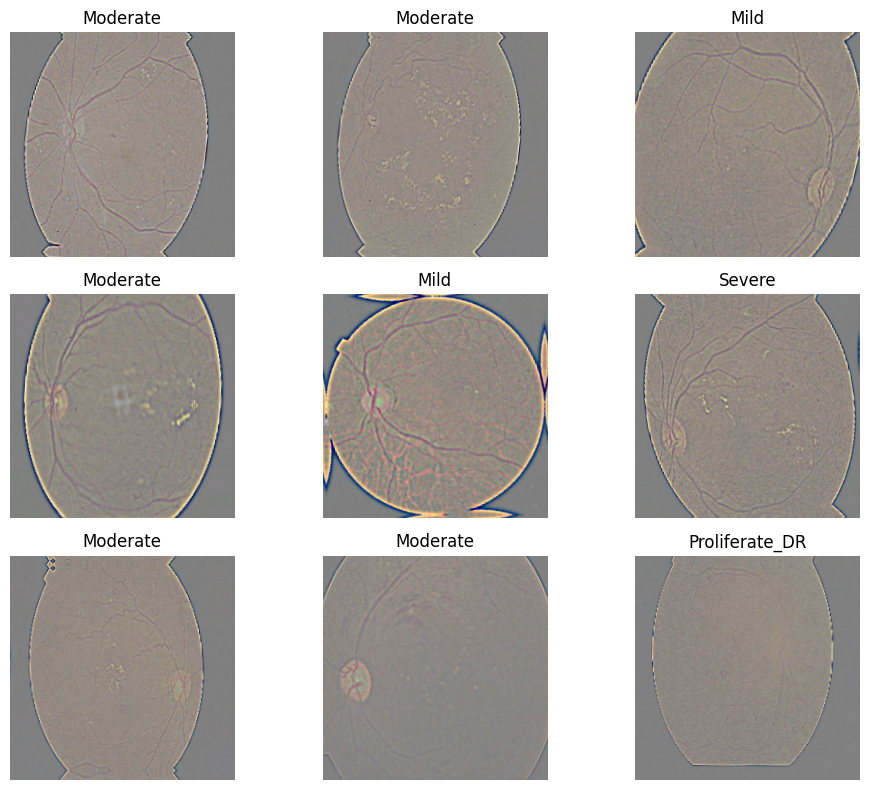

In [26]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(classes[labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(5, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [29]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert labels to integers
train_labels = train_df["label"].map(label_map).values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(
    zip(np.unique(train_labels), class_weights)
)

print("Class weights:")

for class_id, weight in class_weights.items():
    print(f"{class_id} ({classes[class_id]}): {weight:.2f}")

Class weights:
0 (No_DR): 0.41
1 (Mild): 1.98
2 (Moderate): 0.73
3 (Severe): 3.80
4 (Proliferate_DR): 2.48


In [30]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 372s 4s/step - accuracy: 0.4042 - loss: 1.6006 - val_accuracy: 0.6284 - val_loss: 1.0058
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.5835 - loss: 1.4232 - val_accuracy: 0.6694 - val_loss: 0.9163
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - accuracy: 0.5613 - loss: 1.4011 - val_accuracy: 0.6612 - val_loss: 0.8919
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 344s 4s/step - accuracy: 0.5493 - loss: 1.3337 - val_accuracy: 0.6940 - val_loss: 0.8792
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step - accuracy: 0.5456 - loss: 1.3389 - val_accuracy: 0.6421 - val_loss: 1.0234
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 335s 4s/step - accuracy: 0.5128 - loss: 1.3312 - val_accuracy: 0.6749 - val_loss: 0.9877
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 349s 4s/step - accuracy: 0.5603 - loss: 1.3149 - val_accuracy: 0.6776 - val_loss: 0.9208
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 364s 4s/step - accuracy: 0.5596 - loss: 1.2889 - val_accuracy: 0.6667 - v